## Notebook 2 of 5: Per-individual consensus RNA-seq, bulk prediction generation

1. [`01_overview_and_vep.ipynb`](./01_overview_and_vep.ipynb) -- setup, family-aware
   train/test split, gene/ontology descriptions, AlphaGenome reference-only overview plots,
   classical Variant Effect Prediction (VEP).
2. [`02_individual_predictions.ipynb`](./02_individual_predictions.ipynb) -- per-individual
   consensus RNA-seq, comparing two individuals, bulk prediction generation.
3. [`03_population_analysis.ipynb`](./03_population_analysis.ipynb) -- population-level
   comparison, MANE-exon restriction, single-ontology restriction, significance test.
4. [`04_modeling.ipynb`](./04_modeling.ipynb) -- trains a LogisticRegression classifier on
   MANE-exon-restricted features, a second on whole-gene-span features, and a tiny torch MLP
   on the full concatenated signal; persists all three to `notebooks/.cache/models/`.
5. [`05_evaluation.ipynb`](./05_evaluation.ipynb) -- loads the persisted models, evaluates them
   on the held-out test split, reference/variant label prediction, literature-vs-background
   variant comparison.

**This is notebook 2.** It builds per-individual diploid consensus RNA-seq predictions and
caches them under `notebooks/.cache/predictions/` -- notebook 3 (population analysis) reads
that cache but makes no AlphaGenome calls itself, so the more of `notebooks/.cache/predictions/`
this notebook (or `prepare_data.ipynb`'s Step 5 import) has populated, the more individuals
notebook 3's comparisons will cover. Needs `ALPHAGENOME_API_KEY` (see notebook 1).


In [1]:
import os
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path("/home/breno/I2CA/genomics")
NOTEBOOK_DIR = REPO_ROOT / "notebooks"
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))
os.chdir(NOTEBOOK_DIR)

from utils import setup, rna_features
from utils import data as data_utils
from utils import predictions as predictions_utils
from alphagenome.data import genome
from alphagenome.data import transcript as transcript_utils
from alphagenome.data import gene_annotation
from alphagenome.models import dna_client
from alphagenome.visualization import plot_components

ctx = setup.load_experiment(NOTEBOOK_DIR)
GENES, ONTOLOGY_TERMS, CLASS_MAP = ctx.GENES, ctx.ONTOLOGY_TERMS, ctx.CLASS_MAP
WINDOW_CENTER_SIZE = ctx.WINDOW_CENTER_SIZE
gene_rows, individuals, samples_by_class = ctx.gene_rows, ctx.individuals, ctx.samples_by_class
windows_df, gtf = ctx.windows_df, ctx.gtf
CONSENSUS_CACHE_DIR = ctx.CONSENSUS_CACHE_DIR
PREDICTIONS_CACHE_DIR = ctx.PREDICTIONS_CACHE_DIR

train_samples_by_class, test_samples_by_class = setup.get_train_test_split(individuals, CLASS_MAP)
for class_name in samples_by_class:
    print(
        f"{class_name}: {len(samples_by_class[class_name])} total -> "
        f"{len(train_samples_by_class[class_name])} train / {len(test_samples_by_class[class_name])} test"
    )

client, ORGANISM = setup.create_client()
print("AlphaGenome client ready.")


/home/breno/miniforge3/envs/genomics/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


strong pigmentation: 703 total -> 570 train / 133 test
weak pigmentation: 369 total -> 292 train / 77 test
AlphaGenome client ready.


## Individual genomes: strong vs. weak pigmentation, RNA-seq

Instead of predicting on the unmodified reference (as in notebook 1), this builds each sample's
own diploid consensus sequence for a gene's window and runs *that* through AlphaGenome. The
H1/H2 consensus FASTAs are built on the fly with `bcftools consensus`, against
`notebooks/data/variants/<gene>.vcf.gz` (a small, pre-sliced, sample-restricted VCF bundled with
this notebook -- see `notebooks/utils/prepare_data.py`) and
`notebooks/data/references/<gene>/ref.window.fa` as the reference. Results are cached under
`notebooks/.cache/` so repeat runs for the same sample/gene/haplotype are cheap -- see
`notebooks/utils/consensus.py`.

One sample is picked per pigmentation class (from every individual in
`notebooks/data/individuals.json` whose population is in `CLASS_MAP`, not just the ones used to
train a model) and its RNA-seq is plotted the same way as the reference-only plot in notebook 1
(`predict_sequence` instead of `predict_interval`, otherwise the same transcript annotation /
inner-window box).


In [2]:
CLASS_COLORS = {
    "strong pigmentation": "red",
    "weak pigmentation": "gray",
}


def pick_one_sample_per_class() -> dict:
    # Restricted to the train split (not samples_by_class) so this demo never touches a
    # held-out test individual -- deterministically pick the first (sorted) sample_id per class.
    return {
        class_name: {"sample_id": sample_ids[0], "population": individuals[sample_ids[0]]["population"]}
        for class_name, sample_ids in train_samples_by_class.items()
    }


def predict_individual_haplotype(sample_id: str, gene: str, haplotype: str, requested_outputs: list, ontology_terms: list):
    ref_window_fa, gene_vcf_path = data_utils.gene_paths(gene)
    return predictions_utils.predict_haplotype(
        client,
        gene=gene,
        gene_row=gene_rows[gene],
        sample_id=sample_id,
        haplotype=haplotype,
        requested_outputs=requested_outputs,
        ontology_terms=ontology_terms,
        ref_window_fa=ref_window_fa,
        gene_vcf_path=gene_vcf_path,
        consensus_cache_dir=CONSENSUS_CACHE_DIR,
    )


In [3]:
def plot_individual_rna_seq(sample_id: str, class_name: str, population: str, gene: str, ontologies: list):
    gene_data = windows_df.loc[windows_df["gene"] == gene].iloc[0]
    interval = genome.Interval(gene_data["chrom"], gene_data["start"], gene_data["end"])
    inner_interval = interval.resize(WINDOW_CENTER_SIZE)

    gtf_transcripts = gene_annotation.filter_to_mane_select_transcript(
        gene_annotation.filter_protein_coding(gtf)
    )
    transcripts = transcript_utils.TranscriptExtractor(gtf_transcripts).extract(interval)

    output_h1 = predict_individual_haplotype(sample_id, gene, "H1", [dna_client.OutputType.RNA_SEQ], ontologies)
    output_h2 = predict_individual_haplotype(sample_id, gene, "H2", [dna_client.OutputType.RNA_SEQ], ontologies)

    fig = plot_components.plot(
        components=[
            plot_components.TranscriptAnnotation(transcripts),
            plot_components.Tracks(output_h1.rna_seq, ylabel_template="H1 {name}:{strand}"),
            plot_components.Tracks(output_h2.rna_seq, ylabel_template="H2 {name}:{strand}"),
        ],
        annotations=[
            plot_components.IntervalAnnotation(intervals=[inner_interval]),
        ],
        interval=interval,
        title=f"{gene} -- {sample_id} ({population}, {class_name})",
    )
    plt.show()
    plt.close(fig)

def combined_rna_seq_track(sample_id: str, gene: str, ontologies: list):
    """Sum H1 + H2 RNA-seq tracks into one "total expression" track per individual."""
    output_h1 = predict_individual_haplotype(sample_id, gene, "H1", [dna_client.OutputType.RNA_SEQ], ontologies)
    output_h2 = predict_individual_haplotype(sample_id, gene, "H2", [dna_client.OutputType.RNA_SEQ], ontologies)
    return output_h1.rna_seq + output_h2.rna_seq

def plot_rna_seq_comparison(picked_samples: dict, gene: str, ontologies: list):
    gene_data = windows_df.loc[windows_df["gene"] == gene].iloc[0]
    gtf_transcripts_16k = gene_annotation.filter_to_mane_select_transcript(
        gene_annotation.filter_protein_coding(gtf)
    )
    strand = gtf_transcripts_16k.loc[
        (gtf_transcripts_16k["gene_name"] == gene) &
        (gtf_transcripts_16k["Feature"] == "transcript"),
        "Strand"
    ].iloc[0]

    # Zoom width is the whole-gene GTF feature's own span (covering every transcript/isoform),
    # not just the MANE Select transcript's own span. `gene_data` (and therefore the center of
    # `plot_interval_gene` below) is already centered on this same "gene" feature at
    # dataset-build time -- sizing the zoom off the MANE transcript instead can visibly
    # off-center the plot when that one isoform's span sits asymmetrically within the full gene
    # body (observed for DDB1, MFSD12, TYRP1, MC1R).
    gene_span = gtf.loc[
        (gtf["Feature"] == "gene") & (gtf["gene_name"] == gene), ["Start", "End"]
    ].iloc[0]
    zoom_width = int(gene_span["End"] - gene_span["Start"])

    plot_interval_gene = genome.Interval(
        gene_data["chrom"], gene_data["start"], gene_data["end"]
    ).resize(zoom_width)
    transcripts_16k = transcript_utils.TranscriptExtractor(gtf_transcripts_16k).extract(plot_interval_gene)

    if strand == '+':
        overlay_tracks = {
            class_name: combined_rna_seq_track(info["sample_id"], gene, ontologies)
            .filter_to_positive_strand()
            .slice_by_interval(plot_interval_gene)
            for class_name, info in picked_samples.items()
        }
    else:
            overlay_tracks = {
            class_name: combined_rna_seq_track(info["sample_id"], gene, ontologies)
            .filter_to_negative_strand()
            .slice_by_interval(plot_interval_gene)
            for class_name, info in picked_samples.items()
        }

    fig = plot_components.plot(
        components=[
            plot_components.TranscriptAnnotation(transcripts_16k),
            plot_components.OverlaidTracks(
                tdata=overlay_tracks,
                colors=CLASS_COLORS,
                ylabel_template="{name}",
            ),
        ],
        interval=plot_interval_gene,
        title=f"{gene} ({strand} strand) -- strong vs. weak pigmentation, H1+H2 summed",
    )
    ax = fig.axes[1]

    legend = ax.get_legend()
    if legend is not None:
        legend.set_loc("upper left")
    plt.show()
    plt.close(fig)


# Comparing two individuals
1. Pick two individuals from different populations
2. Generate AlphaGenome's RNA-seq prediction for the strand in which the GENE lives.
3. Do it for both haplotypes and calculate the mean.
4. Draw on one shared axis
5. Zoom over the gene's window.


strong pigmentation: HG02461 (GWD)
weak pigmentation: HG00097 (GBR)


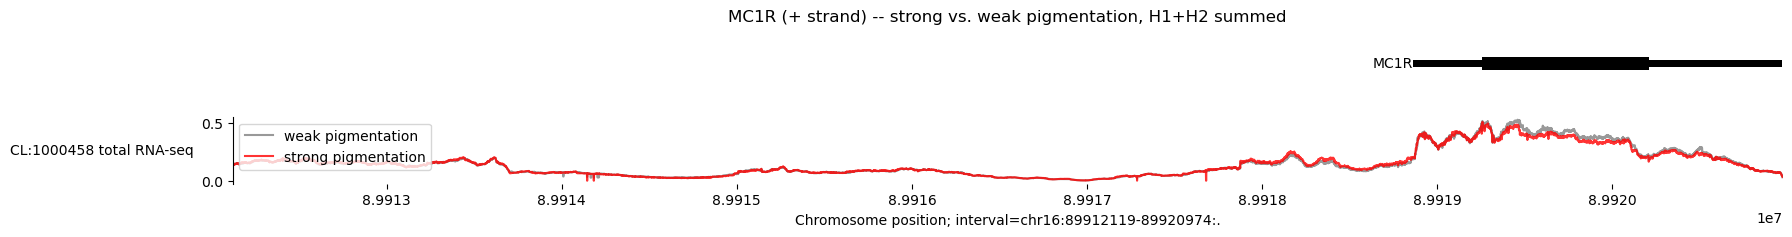

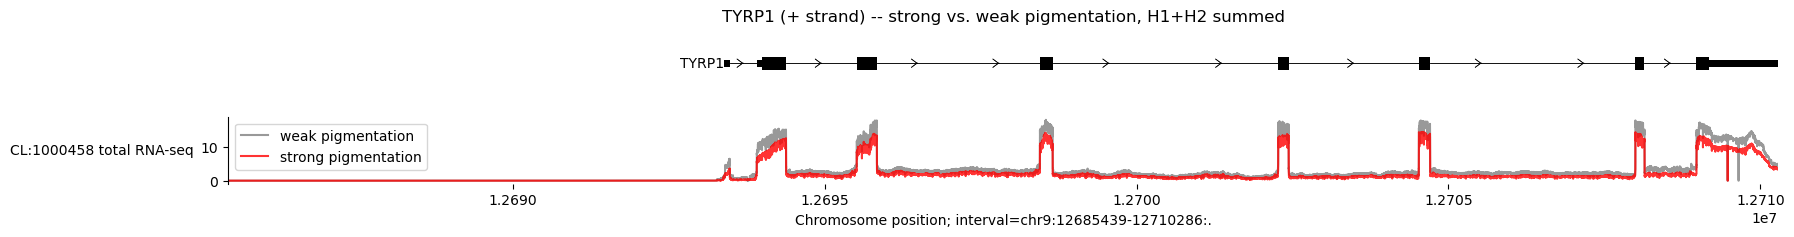

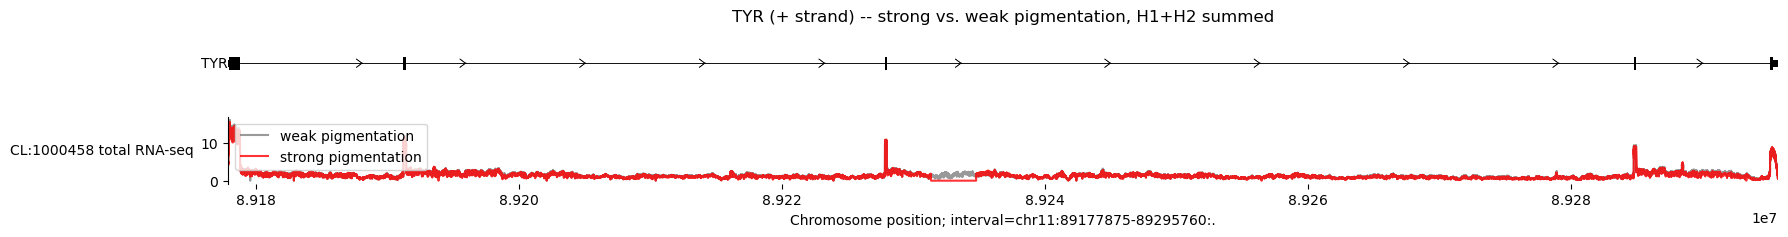

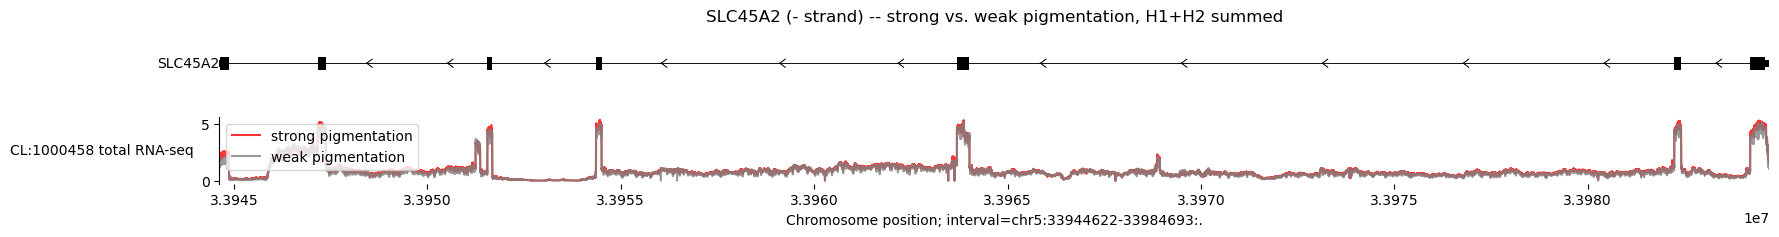

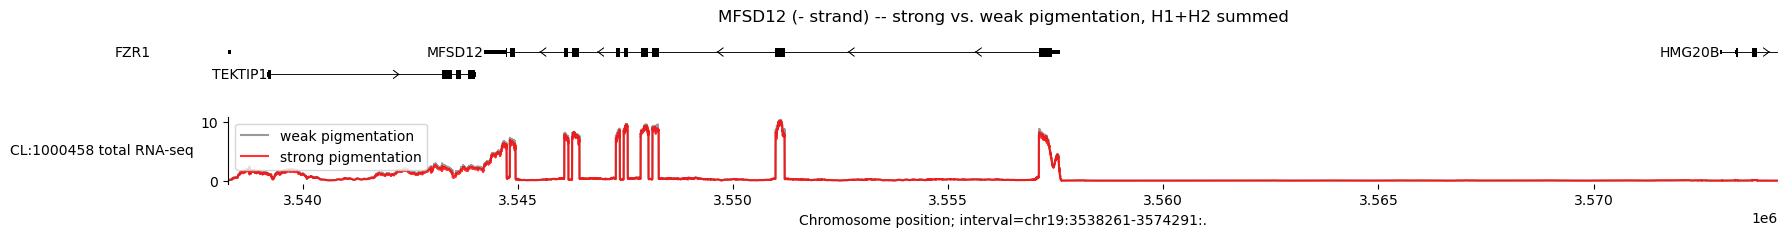

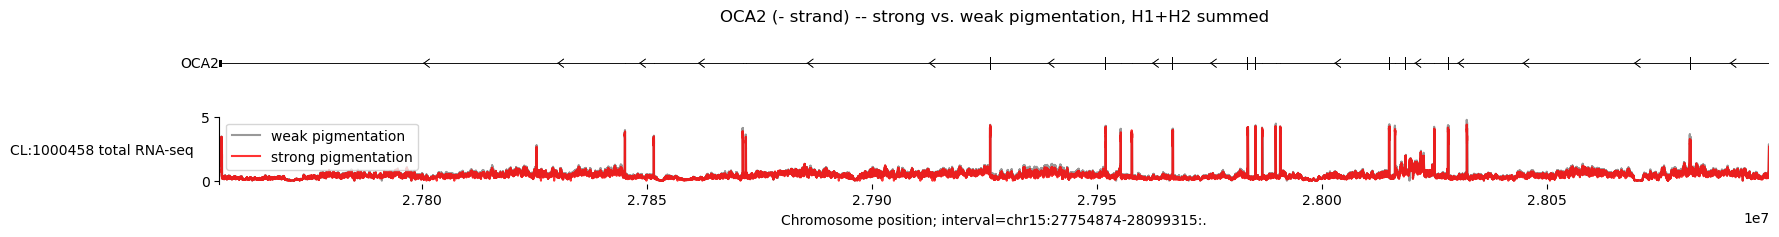

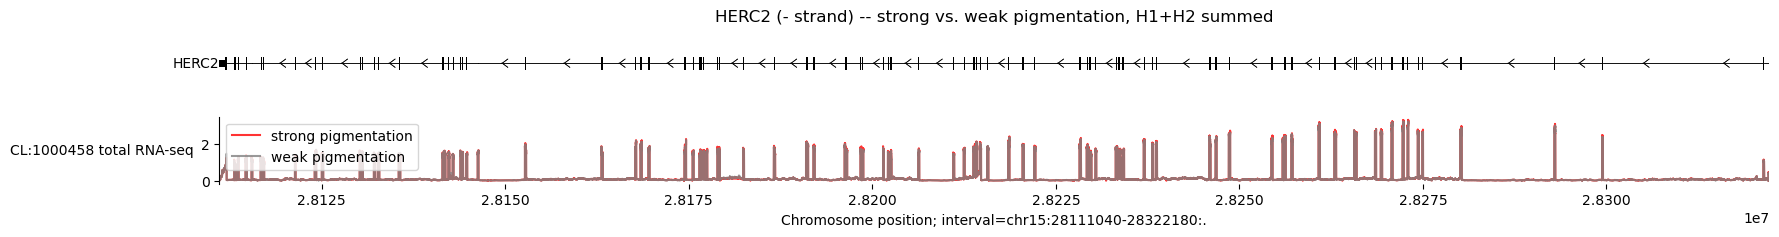

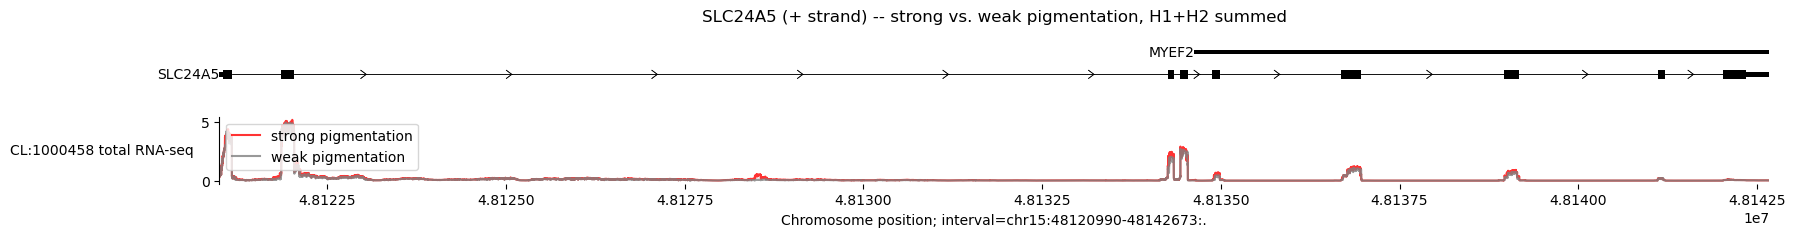

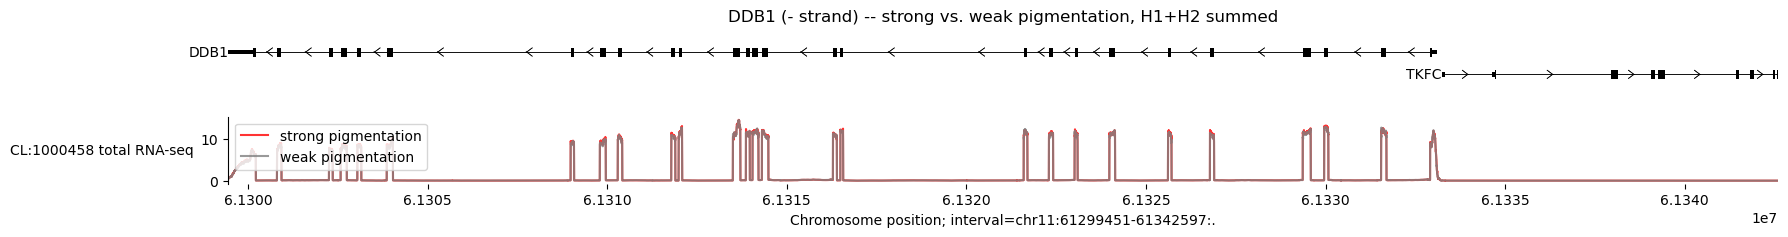

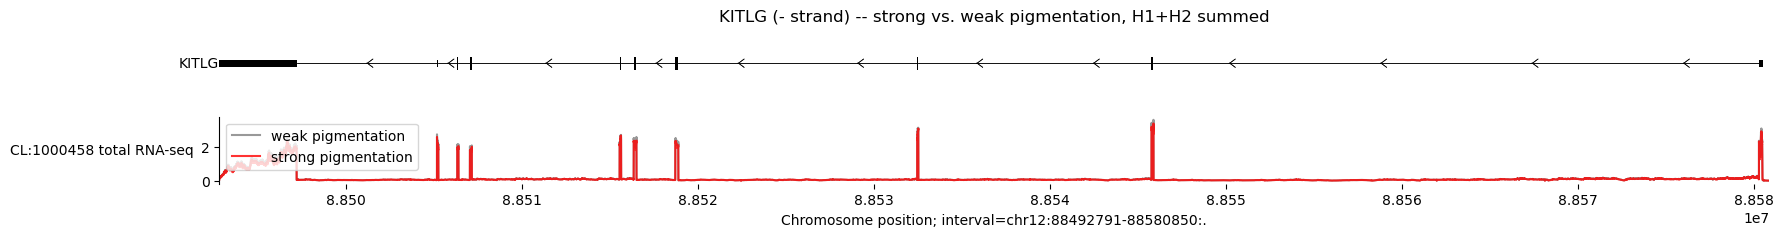

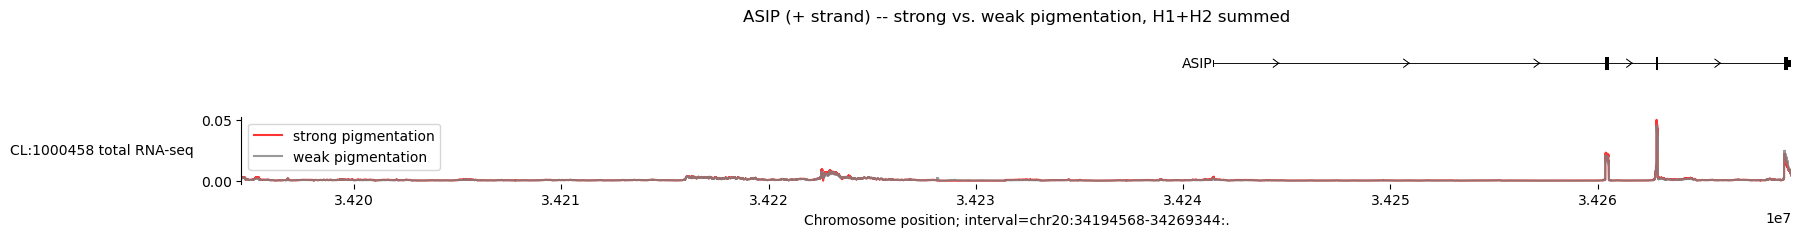

In [4]:
GENE_FOR_COMPARISON = "DDB1"
ONTOLOGY_TERM_FOR_COMPARISON = ONTOLOGY_TERMS[0]

picked_samples = pick_one_sample_per_class()
for class_name, info in picked_samples.items():
    print(f"{class_name}: {info['sample_id']} ({info['population']})")

for gene in GENES:
    plot_rna_seq_comparison(picked_samples, gene, [ONTOLOGY_TERM_FOR_COMPARISON])


## Generating predictions for every strong/weak pigmentation individual

The two comparisons above use one hand-picked individual per class. `notebooks/utils/predictions.py`
generalizes this to *every* individual in `notebooks/data/individuals.json` (1,072 people across the
8 populations in `CLASS_MAP`): for each (gene, sample, haplotype) it builds the consensus FASTA,
predicts, realigns, and caches the result to `notebooks/.cache/predictions/<gene>/<sample>.<haplotype>.npz`.

This is expensive at full scope -- 11 genes x 1,072 individuals x 2 haplotypes is ~23,600 AlphaGenome
API calls. `generate_predictions()` is resumable (skips anything already cached on disk), so it's safe
to widen `genes=`/`sample_ids=` incrementally over multiple runs rather than committing to the full
scope up front. The cell below runs a small demo (one gene, a handful of individuals per class) so you
can see it working before deciding how far to scale it.


In [5]:
# Demo scope: 1 gene x 5 individuals per class x 2 haplotypes = 20 AlphaGenome calls.
# Widen DEMO_GENES / DEMO_N_PER_CLASS (or pass sample_ids=list(individuals) for every
# individual) to scale up -- already-generated (gene, sample, haplotype) results are
# skipped automatically. Drawn from train_samples_by_class, not samples_by_class, so this
# demo doesn't touch held-out test individuals.
DEMO_GENES = ["DDB1"]
DEMO_N_PER_CLASS = 5
demo_sample_ids = [
    sample_id
    for class_name, sample_ids in train_samples_by_class.items()
    for sample_id in sample_ids[:DEMO_N_PER_CLASS]
]
print(f"Demo scope: {len(DEMO_GENES)} gene(s) x {len(demo_sample_ids)} individuals x 2 haplotypes "
      f"= {len(DEMO_GENES) * len(demo_sample_ids) * 2} predictions")

def _on_progress(done, total, gene, sample_id, haplotype, status):
    print(f"[{done}/{total}] {gene} {sample_id} {haplotype}: {status}")

demo_results = predictions_utils.generate_predictions(
    client,
    genes=DEMO_GENES,
    gene_rows=gene_rows,
    gene_paths_fn=data_utils.gene_paths,
    sample_ids=demo_sample_ids,
    ontology_terms=[ONTOLOGY_TERM_FOR_COMPARISON],
    output_dir=PREDICTIONS_CACHE_DIR,
    consensus_cache_dir=CONSENSUS_CACHE_DIR,
    on_progress=_on_progress,
)
pd.DataFrame(demo_results)[["gene", "sample_id", "haplotype", "status"]]


Demo scope: 1 gene(s) x 10 individuals x 2 haplotypes = 20 predictions
[1/20] DDB1 HG02461 H1: cached
[2/20] DDB1 HG02461 H2: cached
[3/20] DDB1 HG02462 H1: cached
[4/20] DDB1 HG02462 H2: cached
[5/20] DDB1 HG02463 H1: cached
[6/20] DDB1 HG02463 H2: cached
[7/20] DDB1 HG02464 H1: cached
[8/20] DDB1 HG02464 H2: cached
[9/20] DDB1 HG02465 H1: cached
[10/20] DDB1 HG02465 H2: cached
[11/20] DDB1 HG00097 H1: cached
[12/20] DDB1 HG00097 H2: cached
[13/20] DDB1 HG00100 H1: cached
[14/20] DDB1 HG00100 H2: cached
[15/20] DDB1 HG00101 H1: cached
[16/20] DDB1 HG00101 H2: cached
[17/20] DDB1 HG00105 H1: cached
[18/20] DDB1 HG00105 H2: cached
[19/20] DDB1 HG00106 H1: cached
[20/20] DDB1 HG00106 H2: cached


,gene,sample_id,haplotype,status
0,DDB1,HG02461,H1,cached
1,DDB1,HG02461,H2,cached
2,DDB1,HG02462,H1,cached
3,DDB1,HG02462,H2,cached
4,DDB1,HG02463,H1,cached
5,DDB1,HG02463,H2,cached
6,DDB1,HG02464,H1,cached
7,DDB1,HG02464,H2,cached
8,DDB1,HG02465,H1,cached
9,DDB1,HG02465,H2,cached


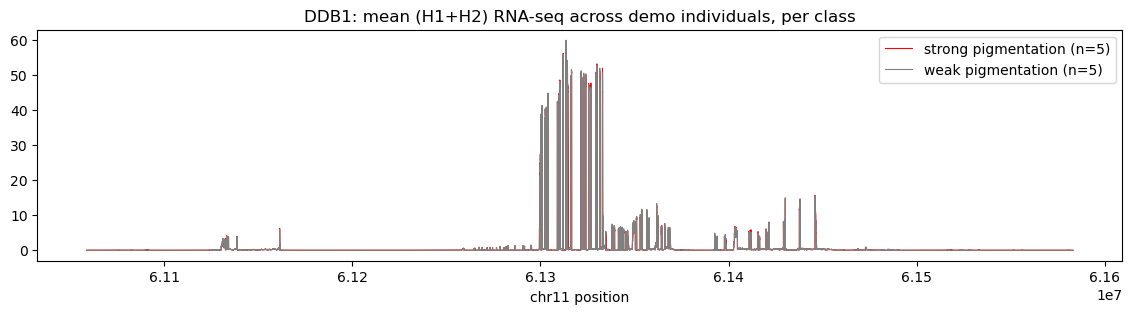

In [6]:
def mean_track_by_class(gene: str, sample_ids_by_class: dict):
    """Averages the (H1+H2) track across every demo individual in each class."""
    return {
        class_name: np.mean(
            [predictions_utils.load_combined_rna_seq(PREDICTIONS_CACHE_DIR, gene, sample_id).values for sample_id in sample_ids],
            axis=0,
        )
        for class_name, sample_ids in sample_ids_by_class.items()
    }


demo_gene = DEMO_GENES[0]
demo_sample_ids_by_class = {
    class_name: [s for s in sample_ids[:DEMO_N_PER_CLASS]]
    for class_name, sample_ids in train_samples_by_class.items()
}
mean_tracks = mean_track_by_class(demo_gene, demo_sample_ids_by_class)

gene_data = windows_df.loc[windows_df["gene"] == demo_gene].iloc[0]
positions = np.arange(gene_data["start"], gene_data["end"])

fig, ax = plt.subplots(figsize=(14, 3))
for class_name, track in mean_tracks.items():
    ax.plot(positions, track.sum(axis=1), label=f"{class_name} (n={len(demo_sample_ids_by_class[class_name])})",
            color=CLASS_COLORS[class_name], linewidth=0.8)
ax.set_title(f"{demo_gene}: mean (H1+H2) RNA-seq across demo individuals, per class")
ax.set_xlabel(f"{gene_data['chrom']} position")
ax.legend()
plt.show()
plt.close(fig)
